In [1]:
import os, pickle

import sys
sys.path.insert(1, '..')

from physics.simulation import mcfm, msq
from physics.hzz import zpair, zz4l
from datasets import jointlikelihood
from models import alice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from sklearn.preprocessing import StandardScaler
import hist

import torch
from lightning import Trainer

In [2]:
OUTPUT_DIR = '../jobs/alice/refactor-four-SBI-vs-BKG'
SCALER_FILE_X = 'scaler.pkl'
SCALER_FILE_Y = None
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

EPOCH = 63
VAL_LOSS = 0.69
VERSION = 0

CHECKPOINT = f'checkpoint-alice-epoch={EPOCH}-val_loss={VAL_LOSS}.ckpt'
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_NUMERATOR = msq.Component.SBI
COMPONENT_DENOMINATOR = msq.Component.BKG

COMPONENT_FILE = msq.Component.SBI

SAMPLE_SIZE = 150000

FEATURES=['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

BATCH_SIZE = 256
SEED = 42

In [3]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

comp_strings = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.BKG : 'BKG',
    msq.Component.INT : 'INT'
}

In [4]:
datamodule = jointlikelihood.AliceDataModule(
    filepath=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]),
    features=['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity'],
    numerator_component=COMPONENT_NUMERATOR,
    denominator_component=COMPONENT_DENOMINATOR,
    sample_size=SAMPLE_SIZE,
    batch_size=BATCH_SIZE,
    random_state=SEED,
    scaler_path=None
)

In [5]:
events = mcfm.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]), n_rows=int(SAMPLE_SIZE*1.2)).reweight(COMPONENT_FILE, COMPONENT_DENOMINATOR)
        
z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

events_processed = events.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

0.9683032093209168


In [6]:
events_train, events_val = events_processed.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)

training_data = jointlikelihood.JointLikelihoodDataset(events_train, features=FEATURES, numerator_component=COMPONENT_NUMERATOR, denominator_component=COMPONENT_DENOMINATOR, sample_size=SAMPLE_SIZE, random_state=SEED)
validation_data = jointlikelihood.JointLikelihoodDataset(events_val, features=FEATURES, numerator_component=COMPONENT_NUMERATOR, denominator_component=COMPONENT_DENOMINATOR, sample_size=SAMPLE_SIZE, random_state=SEED)


if SCALER_FILE_X is not None:
    with open(os.path.join(OUTPUT_DIR, SCALER_FILE_X), 'rb') as f:
        scaler_X = pickle.load(f)
    
    training_data.X = scaler_X.transform(training_data.X)
    validation_data.X = scaler_X.transform(validation_data.X)

if SCALER_FILE_Y is not None:
    with open(os.path.join(OUTPUT_DIR, SCALER_FILE_Y), 'rb') as f:
        scaler_s = pickle.load(f)
    
    training_data.s = scaler_s.transform(training_data.s)
    validation_data.s = scaler_s.transform(validation_data.s)

In [7]:
loaded_model = alice.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [8]:
predictions_train = loaded_model(torch.tensor(training_data.X, dtype=torch.float32)).detach().view(-1).numpy()
targets_train = training_data.s

In [9]:
predictions_val = loaded_model(torch.tensor(validation_data.X, dtype=torch.float32)).detach().view(-1).numpy()
targets_val = validation_data.s

In [10]:
targets_train=training_data.s
targets_val=validation_data.s

In [11]:
ratios_train_pred = predictions_train/(1-predictions_train)
ratios_train_target = targets_train/(1-targets_train)

ratios_val_pred = predictions_val/(1-predictions_val)
ratios_val_target = targets_val/(1-targets_val)

/tmp/ipykernel_646061/2998033943.py:42: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
/tmp/ipykernel_646061/2998033943.py:43: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')
/tmp/ipykernel_646061/2998033943.py:49: RuntimeWarning: invalid value encountered in divide
  ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variance

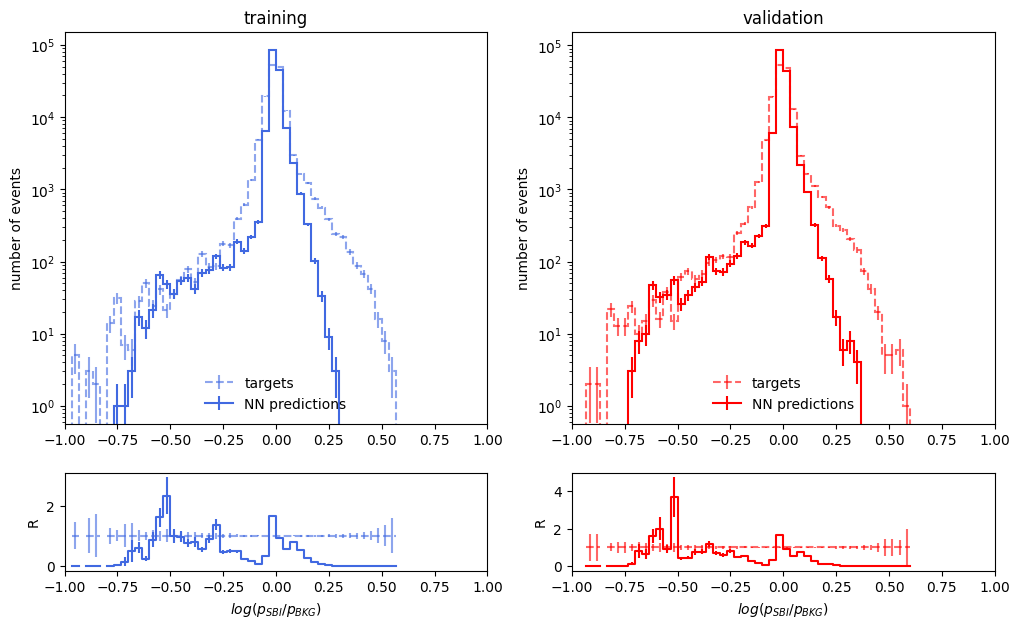

In [12]:
BINS = 60

bounds = [-1,1]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_train.fill(np.log(ratios_train_pred))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_train.fill(np.log(ratios_train_target))


h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_val.fill(np.log(ratios_val_pred))

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_val.fill(np.log(ratios_val_target))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, gridspec_kw={'height_ratios': [4, 1]}, figsize=(12,7))

h_targets_train.plot(ax=ax1, color='royalblue', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_train.variances()))
h_predictions_train.plot(ax=ax1, color='royalblue', linestyle='-', label='NN predictions', yerr=np.sqrt(h_predictions_train.variances()))

h_targets_val.plot(ax=ax2, color='red', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_val.variances()))
h_predictions_val.plot(ax=ax2, color='red', label='NN predictions', yerr=np.sqrt(h_predictions_val.variances()))

ax1.set_title('training')
ax1.set_xlabel('')
ax3.set_xlabel(f'$log(p_{{{comp_strings[COMPONENT_NUMERATOR]}}}/p_{{{comp_strings[COMPONENT_DENOMINATOR]}}})$')
ax1.set_ylabel('number of events')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.legend(loc='lower center', frameon=False)

ax2.set_title('validation')
ax2.set_xlabel('')
ax4.set_xlabel(f'$log(p_{{{comp_strings[COMPONENT_NUMERATOR]}}}/p_{{{comp_strings[COMPONENT_DENOMINATOR]}}})$')
ax2.set_ylabel('number of events')
ax2.set_yscale('log')
ax2.set_xlim(*bounds)
ax2.legend(loc='lower center', frameon=False)

ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')

#ax3.set_ylim(0,3)
ax3.set_ylabel('R')
ax3.set_xlim(*bounds)

ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variances())/h_targets_val.values(), color='red', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax4.errorbar(h_predictions_val.axes[0].centers, h_predictions_val.values()/h_targets_val.values(), yerr=np.sqrt((np.sqrt(h_predictions_val.variances())/h_targets_val.values())**2 + (- np.sqrt(h_targets_val.variances())*h_predictions_val.values()/h_targets_val.values()**2)**2), color='red', drawstyle='steps-mid', label=f'')

#ax4.set_ylim(0,3)
ax4.set_ylabel('R')
ax4.set_xlim(*bounds)

plt.show()

/tmp/ipykernel_646061/906833300.py:42: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
/tmp/ipykernel_646061/906833300.py:43: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')
/tmp/ipykernel_646061/906833300.py:48: RuntimeWarning: invalid value encountered in divide
  ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variances()

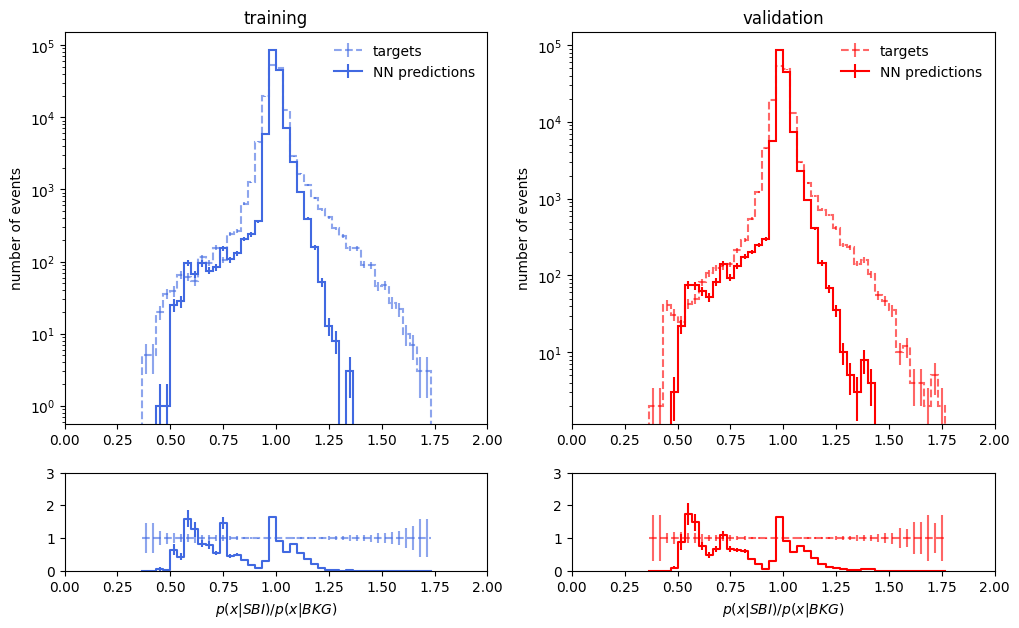

In [13]:
BINS = 60

bounds = [0,2]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_train.fill(ratios_train_pred)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_train.fill(ratios_train_target)


h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_val.fill(ratios_val_pred)

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_val.fill(ratios_val_target)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, gridspec_kw={'height_ratios': [4, 1]}, figsize=(12,7))

h_targets_train.plot(ax=ax1, color='royalblue', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_train.variances()))
h_predictions_train.plot(ax=ax1, color='royalblue', linestyle='-', label='NN predictions', yerr=np.sqrt(h_predictions_train.variances()))

h_targets_val.plot(ax=ax2, color='red', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_val.variances()))
h_predictions_val.plot(ax=ax2, color='red', label='NN predictions', yerr=np.sqrt(h_predictions_val.variances()))

ax1.set_title('training')
ax1.set_xlabel('')
ax3.set_xlabel(f'$p(x|{comp_strings[COMPONENT_NUMERATOR]})/p(x|{comp_strings[COMPONENT_DENOMINATOR]})$')
ax1.set_ylabel('number of events')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.legend(loc='upper right', frameon=False)

ax2.set_title('validation')
ax2.set_xlabel('')
ax4.set_xlabel(f'$p(x|{comp_strings[COMPONENT_NUMERATOR]})/p(x|{comp_strings[COMPONENT_DENOMINATOR]})$')
ax2.set_ylabel('number of events')
ax2.set_yscale('log')
ax2.set_xlim(*bounds)
ax2.legend(loc='upper right', frameon=False)

ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')

ax3.set_ylim(0,3)
ax3.set_xlim(*bounds)

ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variances())/h_targets_val.values(), color='red', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax4.errorbar(h_predictions_val.axes[0].centers, h_predictions_val.values()/h_targets_val.values(), yerr=np.sqrt((np.sqrt(h_predictions_val.variances())/h_targets_val.values())**2 + (- np.sqrt(h_targets_val.variances())*h_predictions_val.values()/h_targets_val.values()**2)**2), color='red', drawstyle='steps-mid', label=f'')

ax4.set_ylim(0,3)
ax4.set_xlim(*bounds)

plt.show()

[-0.4768613  -0.37360498 -0.38942778 -0.37125236 -0.2249592  -0.2678737
 -0.2884459  -0.26289895 -0.21938877 -0.20161663 -0.13011542 -0.13884741
 -0.08669867 -0.04836575 -0.07698178 -0.04381004 -0.02187331 -0.01060019
 -0.00891051 -0.00190838 -0.00286471 -0.00942984 -0.01324245 -0.0133764
 -0.0097838  -0.00197511  0.0058879   0.01125011  0.01469346  0.02333786
  0.03042504  0.03880962  0.04172395  0.04517226  0.05255852  0.05547896
  0.05328401  0.0537653   0.06112193  0.06626186  0.07132737  0.07325006
  0.06413331  0.0632649   0.11184818  0.05952596  0.07521282  0.1039278
  0.08994839  0.07431336]
[-0.49090178 -0.46918444 -0.44895151 -0.43247688 -0.40852423 -0.39066223
 -0.36874481 -0.35354683 -0.3288808  -0.30836699 -0.29001324 -0.2720337
 -0.24997879 -0.22876278 -0.21129101 -0.19060006 -0.16973867 -0.14869879
 -0.12849472 -0.10920358 -0.08872531 -0.0684782  -0.04874518 -0.02892024
 -0.00956531  0.00945189  0.02873797  0.04794647  0.06877381  0.08935386
  0.10972519  0.12935894  0.1

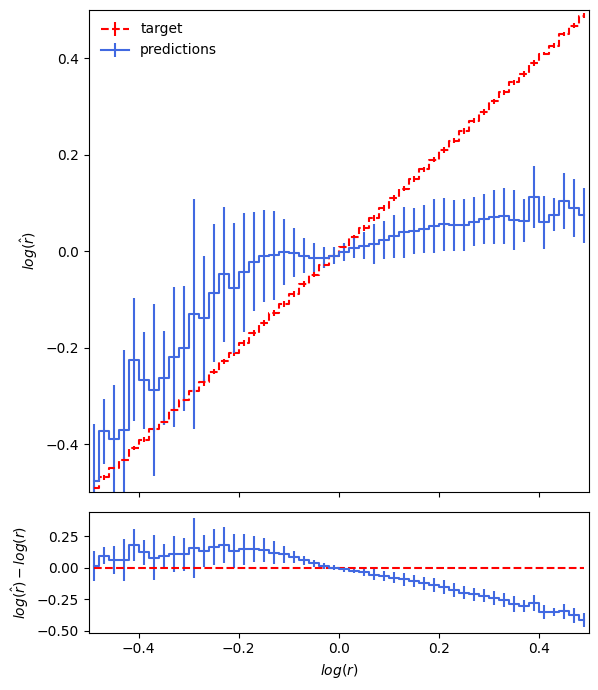

In [29]:
BINS=50

bounds = [-0.5,0.5]

step_size = (bounds[1]-bounds[0])/BINS

binned_pred = [np.log(ratios_val_pred[np.where((np.log(ratios_val_target)>=i*step_size+bounds[0])&(np.log(ratios_val_target)<(i+1)*step_size+bounds[0]))]) for i in range(BINS)]
average_preds = np.array([np.mean(el) for el in binned_pred])
std_dev_preds = np.array([np.std(el) for el in binned_pred])

binned_target = [np.log(ratios_val_target[np.where((np.log(ratios_val_target)>=i*step_size+bounds[0])&(np.log(ratios_val_target)<(i+1)*step_size+bounds[0]))]) for i in range(BINS)]
average_targets = np.array([np.mean(el) for el in binned_target])
std_dev_targets = np.array([np.std(el) for el in binned_target])

centers = [(i+1/2)*step_size+bounds[0] for i in range(BINS)]

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, average_targets, yerr=std_dev_targets, drawstyle='steps-mid', color='red', linestyle='--', label='target')
ax1.errorbar(centers, average_preds, yerr=std_dev_preds, drawstyle='steps-mid', color='royalblue', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$log(\hat{r})$')

ax1.legend(frameon=False)

print(average_preds)
print(average_targets)
print(average_preds/average_targets)

ax2.errorbar(centers, average_targets-average_targets, drawstyle='steps-mid', color='red', linestyle='--', label='target')
ax2.errorbar(centers, average_preds-average_targets, yerr=(std_dev_preds**2 + std_dev_targets**2)**(1/2), drawstyle='steps-mid', color='royalblue', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$log(r)$')
ax2.set_ylabel('$log(\hat{r}) - log(r)$')

plt.tight_layout()

plt.show()

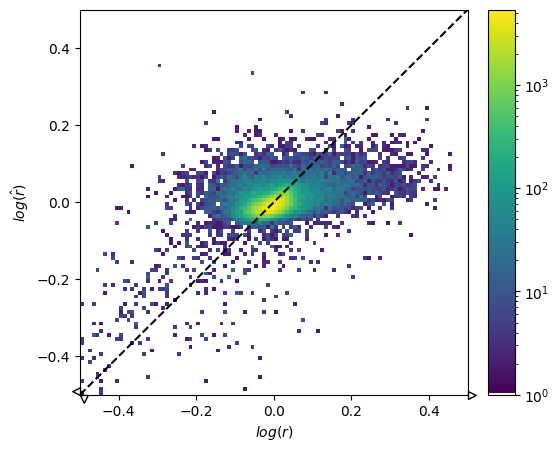

In [15]:
BINS=100

bounds = [-0.5,0.5]

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name='$log(\hat{r})$')
)

h_calibration_val.fill(np.log(ratios_val_target), np.log(ratios_val_pred))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_val.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

plt.show()

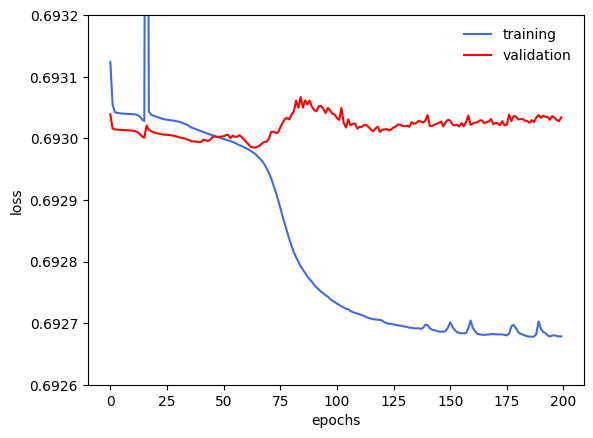

In [16]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')

plt.ylim(0.6926,0.6932)

plt.legend(frameon=False)

plt.show()